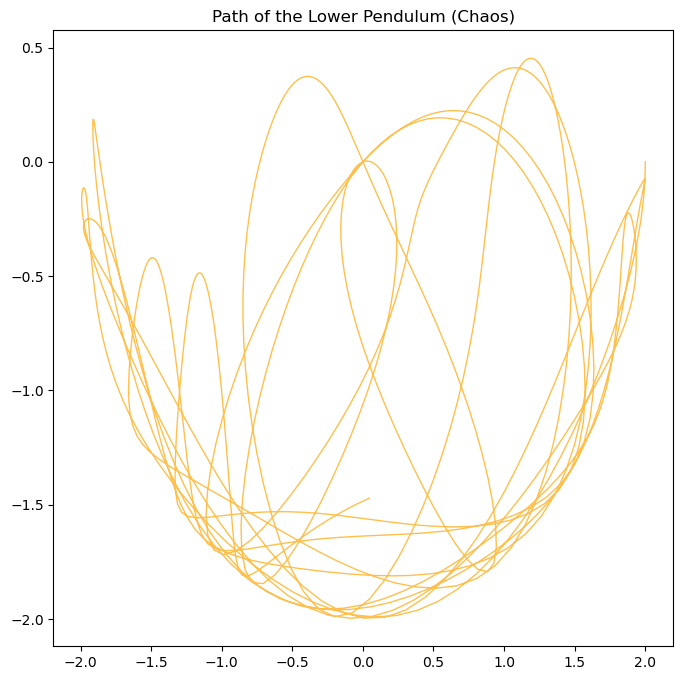

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def der_state(state, t, G=9.8, L1=1.0, L2=1.0, M1=1.0, M2=1.0):
    # Math for the acceleration of the two angles
    th1, w1, th2, w2 = state
    dth1 = w1
    dth2 = w2
    
    delta = th2 - th1
    den1 = (M1 + M2) * L1 - M2 * L1 * np.cos(delta) * np.cos(delta)
    dw1 = (M2 * L1 * w1**2 * np.sin(delta) * np.cos(delta) +
           M2 * G * np.sin(th2) * np.cos(delta) +
           M2 * L2 * w2**2 * np.sin(delta) -
           (M1 + M2) * G * np.sin(th1)) / den1
           
    den2 = (L2 / L1) * den1
    dw2 = (-M2 * L2 * w2**2 * np.sin(delta) * np.cos(delta) +
           (M1 + M2) * G * np.sin(th1) * np.cos(delta) -
           (M1 + M2) * L1 * w1**2 * np.sin(delta) -
           (M1 + M2) * G * np.sin(th2)) / den2
           
    return [dth1, dw1, dth2, dw2]

# Time array
t = np.linspace(0, 20, 1000)
# Initial state: [angle1, speed1, angle2, speed2]
y0 = [np.pi/2, 0, np.pi/2, 0]

sol = odeint(der_state, y0, t)

# Convert to XY coordinates for plotting
x1 = np.sin(sol[:, 0])
y1 = -np.cos(sol[:, 0])
x2 = x1 + np.sin(sol[:, 2])
y2 = y1 - np.cos(sol[:, 2])

plt.figure(figsize=(8, 8))
plt.plot(x2, y2, lw=1, color='orange', alpha=0.7)
plt.title("Path of the Lower Pendulum (Chaos)")
plt.savefig('double_pendulum_test.png')